In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [33]:
df = pd.read_csv("monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [34]:
print(df.shape)
df.info()

(168, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [35]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [36]:
date_col = None
for col in df.columns:
    if "month" in col.lower() or "date" in col.lower() or "time" in col.lower():
        date_col = col
        break

print("Detected date column:", date_col)

Detected date column: Date


In [37]:
df[date_col] = pd.to_datetime(df[date_col])
df.set_index(date_col, inplace=True)

In [38]:
# Detect numeric column
value_col = df.select_dtypes(include=['float64','int64']).columns[0]

print("Detected numeric column:", value_col)


Detected numeric column: Production


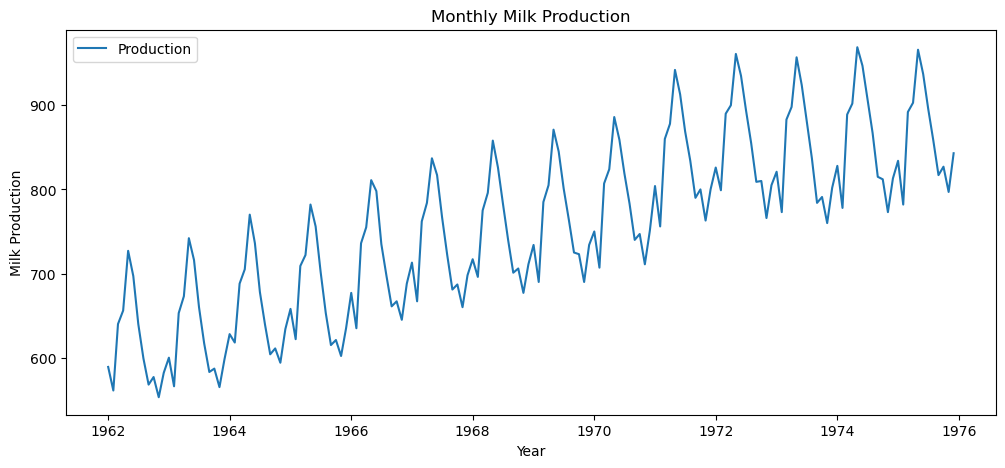

In [39]:
plt.figure(figsize=(12,5))
plt.plot(df[value_col], label=value_col)
plt.title("Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [40]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[[value_col]])

In [41]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)
window = 12
X, y = create_sequences(scaled_data, window)

In [42]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


In [43]:
train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
X_train.shape, X_test.shape

((124, 12, 1), (32, 12, 1))

In [44]:
# RNN Model
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_rnn = rnn_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0978 - val_loss: 0.0107
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0190 - val_loss: 0.0881
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0124 - val_loss: 0.0042
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0082 - val_loss: 0.0042
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0045 - val_loss: 0.0205
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0046 - val_loss: 0.0056
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0032 - val_loss: 0.0038
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - val_loss: 0.0075
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - val_loss: 0.0044
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0021 - val_loss: 0.0040
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0020 - val_loss: 0.0034
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - val_loss: 0.0038
E

In [ ]:
# LSTM Model
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

In [ ]:
history_lstm = lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


In [ ]:
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

In [ ]:
history_gru = gru_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)


In [ ]:
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    pred = scaler.inverse_transform(pred)
    actual = scaler.inverse_transform(y_test)
    
    rmse = math.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    
    return rmse, mae, pred

In [ ]:
rnn_rmse, rnn_mae, rnn_pred = evaluate(rnn_model, X_test, y_test)
rnn_rmse, rnn_mae

In [ ]:
lstm_rmse, lstm_mae, lstm_pred = evaluate(lstm_model, X_test, y_test)
lstm_rmse, lstm_mae

In [29]:
gru_rmse, gru_mae, gru_pred = evaluate(gru_model, X_test, y_test)
gru_rmse, gru_mae

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


(300.03582180609993, 293.88587760925293)

NameError: name 'lstm_pred' is not defined

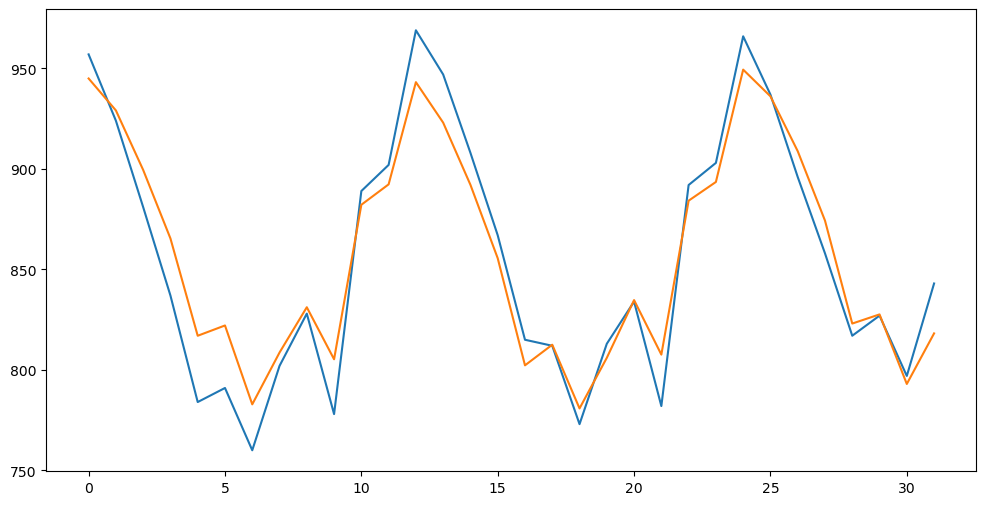

In [30]:
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(y_test), label="Actual")
plt.plot(rnn_pred, label="RNN")
plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [29]:
def forecast_next(model, last_seq, steps=12):
    result = []
    seq = last_seq.copy()

    for _ in range(steps):
        pred = model.predict(seq.reshape(1,window,1))[0]
        result.append(pred)
        seq = np.append(seq[1:], pred).reshape(window,1)
    return np.array(result)

In [30]:
last_seq = scaled_data[-window:]
future = forecast_next(lstm_model, last_seq, 12)
future = scaler.inverse_transform(future)
future

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[834.6408 ],
       [847.933  ],
       [883.1169 ],
       [906.8093 ],
       [927.4487 ],
       [926.7312 ],
       [912.8904 ],
       [891.6761 ],
       [869.79156],
       [857.15656],
       [846.01324],
       [849.68536]], dtype=float32)

In [31]:
plt.figure(figsize=(12,5))
plt.plot(future, marker='o', label='Next 12 Months Forecast')
plt.title("Future Milk Production Forecast")
plt.xlabel("Months Ahead")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

NameError: name 'future' is not defined

<Figure size 1200x500 with 0 Axes>